# Tutorial

_Copyright (c) 2026, National Technology and Engineering Solutions of Sandia, LLC_

This notebook covers the basic calling sequences for SUPN initialization, training, and interrogation. As an example, we will use the target function
$$
f(x, y) = x \sin(7 \pi x) y \sin(3\pi y), \qquad x, y \in [0, 1].
$$

In [1]:
import torch
torch.manual_seed(6282020)
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 200
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (5, 4)
import copy
from supn import SUPN

In [2]:
def f(x):
    return (x[:, 0]*x[:, 1] * torch.sin(7*torch.pi*x[:, 0])*torch.sin(3*torch.pi*x[:, 1]))[:, None]

## Initialization

SUPNs have the following arguments at class initialization:

* `max_degree` (int, required): The maximum polynomial degree along any dimension
* `width` (int, required): The number of hidden neurons
* `d` (int, optional): Dimension of inputs, default 1
* `space` (str, optional): Multi-index space for polynomial indices
  * `total_degree`, `hyperbolic_cross`, or `tensor_product`
* `x_train` (torch.Tensor, optional): Training points of shape `(n_train, d)`
  * Used for precomputation of $T_n(x)$
* `domain_transform` (torch.Tensor, optional): Left and right endpoints the domain of each input, shape `(d, 2)`
  * Default $[-1, 1]^d$

In [3]:
(X_train, Y_train) = torch.meshgrid(torch.linspace(0, 1, 51), torch.linspace(0, 1, 51), indexing='ij')
x_train = torch.vstack((X_train.flatten(), Y_train.flatten())).T
y_train = f(x_train)

(X_val, Y_val) = torch.meshgrid(torch.linspace(0.01, 1, 11), torch.linspace(0.01, 1, 11), indexing='ij')
x_val = torch.vstack((X_val.flatten(), Y_val.flatten())).T
y_val = f(x_val)

(X_test, Y_test) = torch.meshgrid(torch.linspace(0, 1, 28), torch.linspace(0, 1, 28), indexing='ij')
x_test = torch.vstack((X_test.flatten(), Y_test.flatten())).T
y_test = f(x_test)

domain_transform = torch.Tensor([[0, 1], [0, 1]])

net = SUPN(max_degree=5, width=10, d=2, space='total_degree', x_train=x_train, domain_transform=domain_transform)

Visualize the multi-index set $\Lambda$. A square at $(3, 2)$ means the basis contains $T_3(x)T_2(y)$.

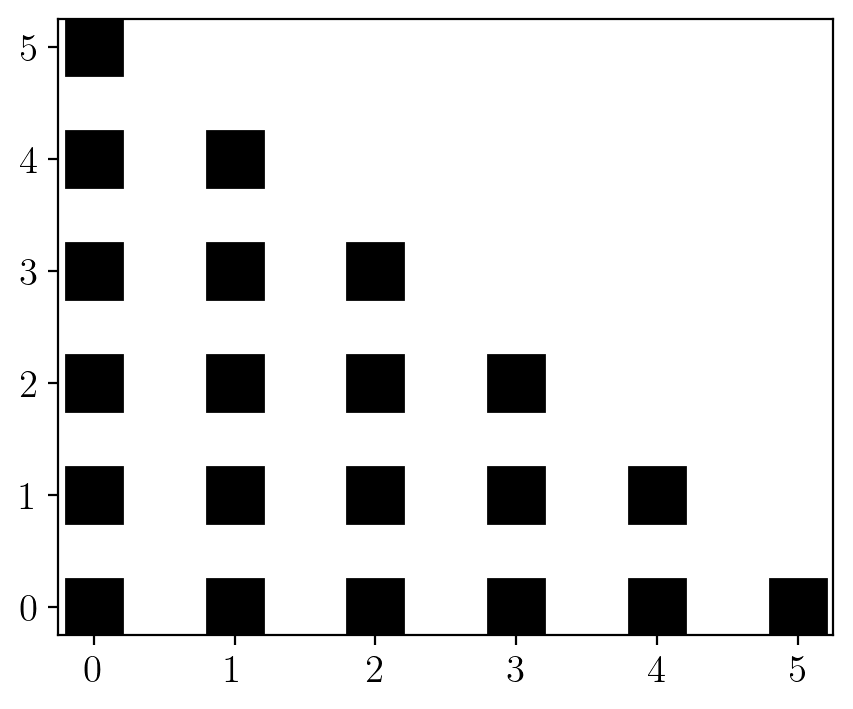

In [4]:
plt.plot(net.Lambda[:, 0], net.Lambda[:, 1], 'ks', markersize=20)
plt.show()

## Optimization

In [5]:
optimizer = torch.optim.Adam(net.parameters(), lr=5e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=33000, eta_min=1e-3)
n_epochs = 100000
for itr in range(n_epochs+1):
    net.zero_grad()
    J = (net(x_train).flatten() - y_train.flatten()).norm() / y_train.flatten().norm()
    J.backward()
    optimizer.step()
    scheduler.step()
    if itr % 1000 == 0:
        J_val = (net(x_val).flatten() - y_val.flatten()).norm() / y_val.flatten().norm()
        test_err = (net(x_test).flatten() - y_test.flatten()).norm() / y_test.flatten().norm()
        print(f'Iteration {itr}: loss_train = {J.item():.2e}, loss_val = {J_val.item():.2e}, rel_l2_err_test = {test_err:.2e}')

Iteration 0: loss_train = 7.75e+00, loss_val = 8.23e+00, rel_l2_err_test = 7.62e+00
Iteration 1000: loss_train = 9.96e-02, loss_val = 1.03e-01, rel_l2_err_test = 9.99e-02
Iteration 2000: loss_train = 6.83e-02, loss_val = 7.36e-02, rel_l2_err_test = 7.07e-02
Iteration 3000: loss_train = 5.80e-02, loss_val = 6.32e-02, rel_l2_err_test = 5.97e-02
Iteration 4000: loss_train = 5.05e-02, loss_val = 5.34e-02, rel_l2_err_test = 5.13e-02
Iteration 5000: loss_train = 4.63e-02, loss_val = 4.81e-02, rel_l2_err_test = 4.66e-02
Iteration 6000: loss_train = 4.40e-02, loss_val = 4.50e-02, rel_l2_err_test = 4.39e-02
Iteration 7000: loss_train = 4.25e-02, loss_val = 4.32e-02, rel_l2_err_test = 4.23e-02
Iteration 8000: loss_train = 4.19e-02, loss_val = 4.26e-02, rel_l2_err_test = 4.13e-02
Iteration 9000: loss_train = 4.05e-02, loss_val = 4.08e-02, rel_l2_err_test = 4.01e-02
Iteration 10000: loss_train = 3.96e-02, loss_val = 3.99e-02, rel_l2_err_test = 3.92e-02
Iteration 11000: loss_train = 3.87e-02, loss_

In [6]:
optimizer = torch.optim.LBFGS(net.parameters(), lr=1e-1)
global iter_count
iter_count = 0
def closure():
    net.zero_grad()
    J = (net(x_train).flatten() - y_train.flatten()).norm() / y_train.flatten().norm()
    J.backward()
    return J

lowest_loss_val = torch.inf
n_epochs = 1000
for itr in range(n_epochs+1):
    optimizer.step(closure)
    if itr % 10 == 0:
        J_train = closure()
        J_val = (net(x_val).flatten() - y_val.flatten()).norm() / y_val.flatten().norm()
        test_err = (net(x_test).flatten() - y_test.flatten()).norm() / y_test.flatten().norm()
        print(f'Iteration {itr}: loss_train = {J_train.item():.2e}, loss_val = {J_val.item():.2e}, rel_l2_err_test = {test_err:.2e}')
        if J_val.item() < lowest_loss_val:
            lowest_loss_val = J_val.item()
            best_model = copy.deepcopy(net)

net = best_model

Iteration 0: loss_train = 2.10e+00, loss_val = 2.14e+00, rel_l2_err_test = 2.11e+00
Iteration 10: loss_train = 2.14e-01, loss_val = 2.21e-01, rel_l2_err_test = 2.24e-01
Iteration 20: loss_train = 8.04e-02, loss_val = 8.41e-02, rel_l2_err_test = 8.51e-02
Iteration 30: loss_train = 5.38e-02, loss_val = 5.33e-02, rel_l2_err_test = 5.41e-02
Iteration 40: loss_train = 4.14e-02, loss_val = 4.42e-02, rel_l2_err_test = 4.34e-02
Iteration 50: loss_train = 3.40e-02, loss_val = 4.30e-02, rel_l2_err_test = 3.46e-02
Iteration 60: loss_train = 2.90e-02, loss_val = 3.32e-02, rel_l2_err_test = 2.98e-02
Iteration 70: loss_train = 2.50e-02, loss_val = 2.96e-02, rel_l2_err_test = 2.59e-02
Iteration 80: loss_train = 2.25e-02, loss_val = 2.70e-02, rel_l2_err_test = 2.32e-02
Iteration 90: loss_train = 2.05e-02, loss_val = 2.50e-02, rel_l2_err_test = 2.13e-02
Iteration 100: loss_train = 1.87e-02, loss_val = 2.14e-02, rel_l2_err_test = 1.93e-02
Iteration 110: loss_train = 1.71e-02, loss_val = 1.97e-02, rel_l2

## Interrogation

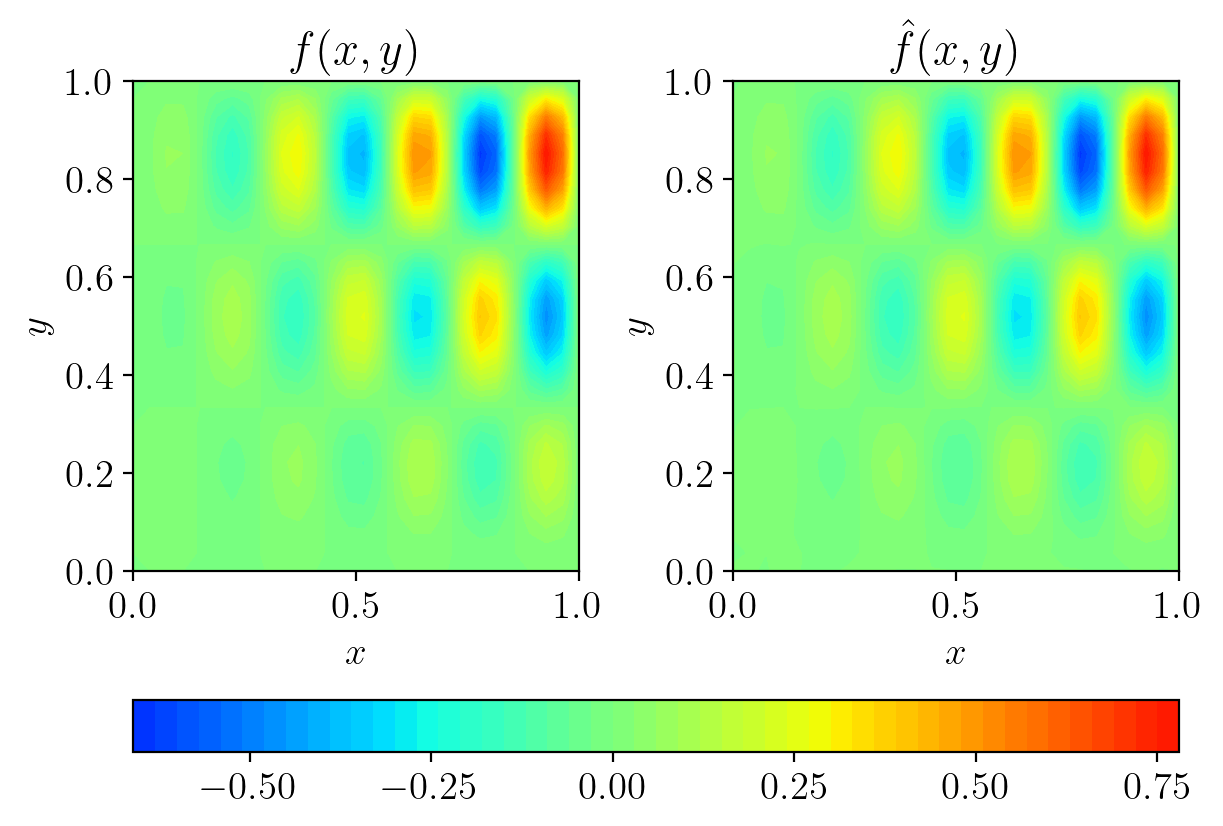

In [7]:

with torch.no_grad():
    preds = net(x_test).reshape(X_test.shape)

fig, ax = plt.subplots(1, 2, layout='constrained')
y_test_plot = ax[0].contourf(X_test, Y_test, y_test.reshape(X_test.shape), cmap='jet', levels=50, vmin=-1, vmax=1)
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')
ax[0].set_title(r'$f(x, y)$')

ax[1].contourf(X_test, Y_test, preds, cmap='jet', levels=50, vmin=-1, vmax=1)
ax[1].set_xlabel(r'$x$')
ax[1].set_ylabel(r'$y$')
ax[1].set_title(r'$\hat{f}(x, y)$')
plt.colorbar(y_test_plot, ax=ax, orientation='horizontal', ticks=torch.arange(-0.75, 0.76, 0.25))

fig.set_size_inches(6, 4)
plt.show()


## Differentiation

SUPNs compute unmixed derivatives up to order 4 analytically (i.e., without automatic differentiation).

In [8]:
derivatives = net.dx(x_test, order=[1, 2, 3])

Above, `order` can be either `list` or `int`.

If `order` is a `list`, the output shape will be `(n_derivatives, d, n_points, n_outputs)`. If `order` is an `int`, then the first dimension is squeezed out.

In [9]:
derivatives.shape

torch.Size([3, 2, 784, 1])

In [10]:
derivatives = net.dx(x_test, order=1)
derivatives.shape

torch.Size([2, 784, 1])

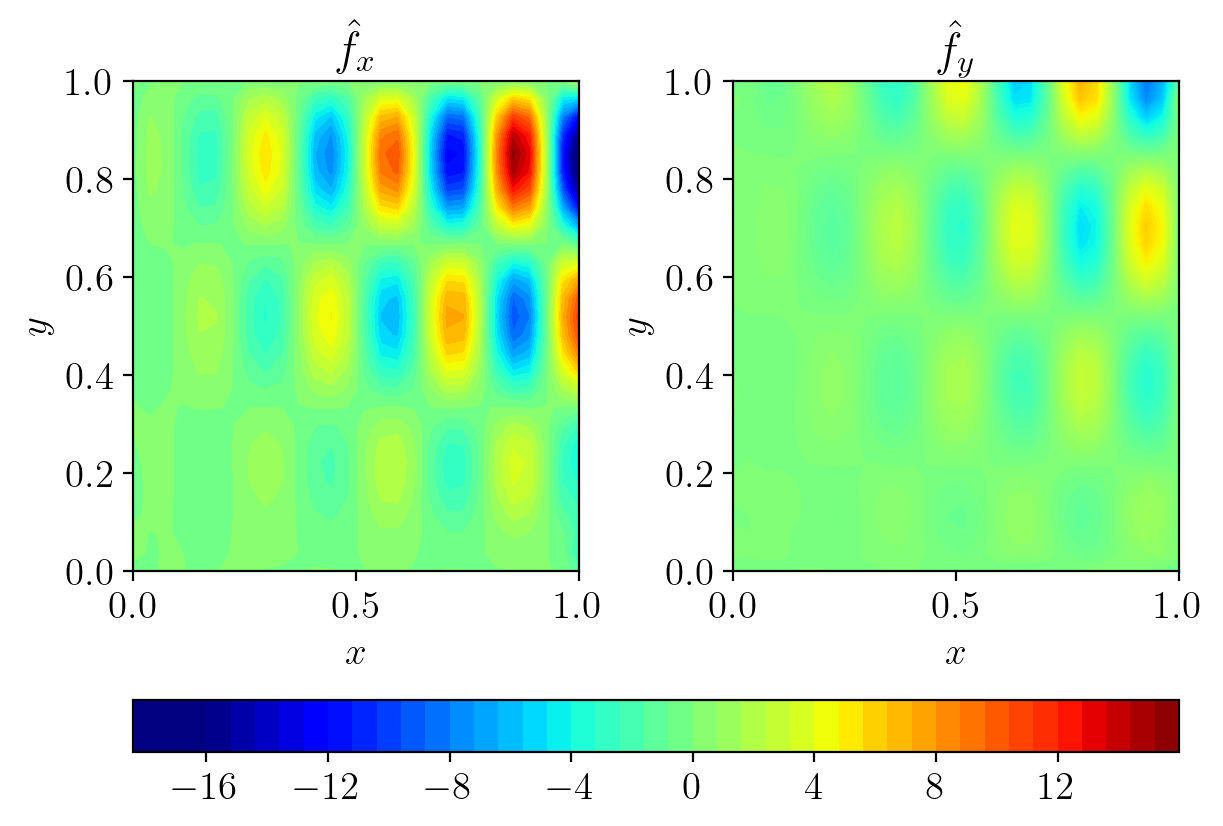

In [11]:
with torch.no_grad():
    fig, ax = plt.subplots(1, 2, layout='constrained')
    y_test_plot = ax[0].contourf(X_test, Y_test, derivatives[0, ...].reshape(X_test.shape), cmap='jet', levels=50, vmin=-16, vmax=16)
    ax[0].set_xlabel(r'$x$')
    ax[0].set_ylabel(r'$y$')
    ax[0].set_title(r'$\hat{f}_x$')

    ax[1].contourf(X_test, Y_test, derivatives[1, ...].reshape(X_test.shape), cmap='jet', levels=50, vmin=-16, vmax=16)
    ax[1].set_xlabel(r'$x$')
    ax[1].set_ylabel(r'$y$')
    ax[1].set_title(r'$\hat{f}_y$')
    plt.colorbar(y_test_plot, ax=ax, orientation='horizontal', ticks=torch.arange(-16, 16, 4))

    fig.set_size_inches(6, 4)
    plt.show()
